<a href="https://colab.research.google.com/github/Ersaoktaviannn/eeg-creative-state-classifier/blob/dev/State_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EKSPLORASI STRUKTUR DATA - DETAIL

In [ ]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# Load satu file untuk eksplorasi
data_path = "/content/drive/MyDrive/Creativity-Dataset/Data_Creativity_Sub_1.mat"
mat_data = sio.loadmat(data_path)

# Lihat isi struktur file .mat
print("=" * 30)
print("STRUKTUR FILE .MAT")
print("=" * 30)
print("Keys dalam file:", mat_data.keys())
print()

# Eksplorasi setiap key
for key in mat_data.keys():
    if not key.startswith('__'):  # Skip metadata
        print(f"\nKey: {key}")
        print(f"  Type: {type(mat_data[key])}")
        print(f"  Shape: {mat_data[key].shape if hasattr(mat_data[key], 'shape') else 'N/A'}")

STRUKTUR FILE .MAT
Keys dalam file: dict_keys(['__header__', '__version__', '__globals__', 'Creativity_1_1_IDE', 'Creativity_1_1_IDG', 'Creativity_1_1_IDR', 'Creativity_1_2_IDE', 'Creativity_1_2_IDG', 'Creativity_1_2_IDR', 'Creativity_1_3_IDE', 'Creativity_1_3_IDG', 'Creativity_1_3_IDR', 'Creativity_1_RST1', 'Creativity_1_RST2'])


Key: Creativity_1_1_IDE
  Type: <class 'numpy.ndarray'>
  Shape: (63, 27000)

Key: Creativity_1_1_IDG
  Type: <class 'numpy.ndarray'>
  Shape: (63, 15000)

Key: Creativity_1_1_IDR
  Type: <class 'numpy.ndarray'>
  Shape: (63, 12000)

Key: Creativity_1_2_IDE
  Type: <class 'numpy.ndarray'>
  Shape: (63, 31000)

Key: Creativity_1_2_IDG
  Type: <class 'numpy.ndarray'>
  Shape: (63, 7000)

Key: Creativity_1_2_IDR
  Type: <class 'numpy.ndarray'>
  Shape: (63, 5000)

Key: Creativity_1_3_IDE
  Type: <class 'numpy.ndarray'>
  Shape: (63, 31000)

Key: Creativity_1_3_IDG
  Type: <class 'numpy.ndarray'>
  Shape: (63, 6000)

Key: Creativity_1_3_IDR
  Type: <class 'numpy

In [ ]:
import scipy.io as sio
import numpy as np
import pandas as pd

# Load data
data_path = "/content/drive/MyDrive/Creativity-Dataset/Data_Creativity_Sub_1.mat"
mat_data = sio.loadmat(data_path)

# Cek apakah ada info channel names di file
print("=" * 60)
print("MENCARI INFORMASI CHANNEL")
print("=" * 60)

for key in mat_data.keys():
    if not key.startswith('__'):
        item = mat_data[key]
        print(f"\n{key}:")
        print(f"  Shape: {item.shape}")
        print(f"  Dtype: {item.dtype}")
        if item.shape[0] == 63:  # Data EEG
            print(f"  Min: {item.min():.2f}, Max: {item.max():.2f}")
            print(f"  Durasi: {item.shape[1]/500:.1f} detik")

# Hitung total durasi untuk klasifikasi biner
print("\n" + "=" * 60)
print("RINGKASAN DATA UNTUK KLASIFIKASI BINER")
print("=" * 60)

# Creative = IDG + IDE + IDR (semua stimulus)
creative_keys = [k for k in mat_data.keys() if 'IDG' in k or 'IDE' in k or 'IDR' in k]
creative_samples = sum(mat_data[k].shape[1] for k in creative_keys)
creative_duration = creative_samples / 500

# Resting = RST1 + RST2
resting_keys = [k for k in mat_data.keys() if 'RST' in k]
resting_samples = sum(mat_data[k].shape[1] for k in resting_keys)
resting_duration = resting_samples / 500

print(f"\n SUBJEK 1:")
print(f"  Creative (IDG+IDE+IDR): {creative_samples} samples = {creative_duration:.1f} detik")
print(f"  Resting (RST1+RST2): {resting_samples} samples = {resting_duration:.1f} detik")

# Estimasi epoch (5 detik, 50% overlap)
epoch_duration = 5  # detik
overlap = 0.5
step = epoch_duration * (1 - overlap)  # 2.5 detik

creative_epochs = int((creative_duration - epoch_duration) / step) + 1
resting_epochs = int((resting_duration - epoch_duration) / step) + 1

print(f"\n ESTIMASI EPOCH (5s, 50% overlap):")
print(f"  Creative epochs: ~{creative_epochs}")
print(f"  Resting epochs: ~{resting_epochs}")
print(f"  Total epochs per subjek: ~{creative_epochs + resting_epochs}")

MENCARI INFORMASI CHANNEL

Creativity_1_1_IDE:
  Shape: (63, 27000)
  Dtype: float64
  Min: -0.01, Max: 0.01
  Durasi: 54.0 detik

Creativity_1_1_IDG:
  Shape: (63, 15000)
  Dtype: float64
  Min: -0.01, Max: 0.01
  Durasi: 30.0 detik

Creativity_1_1_IDR:
  Shape: (63, 12000)
  Dtype: float64
  Min: -0.01, Max: 0.01
  Durasi: 24.0 detik

Creativity_1_2_IDE:
  Shape: (63, 31000)
  Dtype: float64
  Min: -0.01, Max: 0.01
  Durasi: 62.0 detik

Creativity_1_2_IDG:
  Shape: (63, 7000)
  Dtype: float64
  Min: -0.01, Max: 0.01
  Durasi: 14.0 detik

Creativity_1_2_IDR:
  Shape: (63, 5000)
  Dtype: float64
  Min: -0.01, Max: 0.01
  Durasi: 10.0 detik

Creativity_1_3_IDE:
  Shape: (63, 31000)
  Dtype: float64
  Min: -0.01, Max: 0.01
  Durasi: 62.0 detik

Creativity_1_3_IDG:
  Shape: (63, 6000)
  Dtype: float64
  Min: -0.01, Max: 0.01
  Durasi: 12.0 detik

Creativity_1_3_IDR:
  Shape: (63, 4000)
  Dtype: float64
  Min: -0.01, Max: 0.01
  Durasi: 8.0 detik

Creativity_1_RST1:
  Shape: (63, 102000)
 

In [ ]:
import os

dataset_folder = "/content/drive/MyDrive/Creativity-Dataset"

print("=" * 60)
print("FILE DALAM FOLDER DATASET")
print("=" * 60)

for item in os.listdir(dataset_folder):
    item_path = os.path.join(dataset_folder, item)
    if os.path.isfile(item_path):
        size = os.path.getsize(item_path) / 1024  # KB
        print(f"  {item} ({size:.1f} KB)")
    else:
        print(f"  {item}/")

FILE DALAM FOLDER DATASET
  Data_Creativity_Sub_2.mat (115825.9 KB)
  Data_Creativity_Sub_5.mat (119569.8 KB)
  Data_Creativity_Sub_7.mat (138854.0 KB)
  Data_Creativity_Sub_3.mat (160701.6 KB)
  Data_Creativity_Sub_6.mat (166884.9 KB)
  Data_Creativity_Sub_10.mat (170124.6 KB)
  Data_Creativity_Sub_4.mat (202669.5 KB)
  Data_Creativity_Sub_13.mat (136619.5 KB)
  Data_Creativity_Sub_11.mat (185759.7 KB)
  Data_Creativity_Sub_14.mat (157359.2 KB)
  Data_Creativity_Sub_12.mat (231983.6 KB)
  Data_Creativity_Sub_21.mat (187466.2 KB)
  Data_Creativity_Sub_15.mat (231994.2 KB)
  Data_Creativity_Sub_16.mat (246730.5 KB)
  Data_Creativity_Sub_17.mat (246682.7 KB)
  Data_Creativity_Sub_19.mat (146478.3 KB)
  Data_Creativity_Sub_22.mat (206186.6 KB)
  Data_Creativity_Sub_18.mat (196689.4 KB)
  Data_Creativity_Sub_20.mat (202339.7 KB)
  Data_Creativity_Sub_1.mat (156852.0 KB)
  Data_Creativity_Sub_24.mat (135122.2 KB)
  Data_Creativity_Sub_23.mat (181470.8 KB)
  Data_Creativity_Sub_8.mat (235682

# PIPELINE PREPROCESSING

KONFIGURASI PREPROCESSING
Sampling Rate: 500 Hz
Band-pass Filter: 0.5-50.0 Hz
Epoch Duration: 5.0s, Overlap: 50.0%
Selected Channels (16): ['Fp1', 'Fp2', 'F7', 'F3', 'F4', 'F8', 'C3', 'C4', 'T7', 'T8', 'P7', 'P3', 'P4', 'P8', 'O1', 'O2']

MEMULAI PREPROCESSING

Found 28 subjects


Processing subjects: 100%|██████████| 28/28 [03:30<00:00,  7.52s/it]



 Skipped 6 recordings (duration < 5.0s):
   - Sub_10_Creativity_10_3_IDR (too short)
   - Sub_19_Creativity_19_3_IDR (too short)
   - Sub_20_Creativity_20_2_IDR (too short)
   - Sub_20_Creativity_20_3_IDR (too short)
   - Sub_5_Creativity_5_2_IDR (too short)
   - Sub_7_Creativity_7_3_IDR (too short)

HASIL PREPROCESSING
X shape: (8456, 16, 2500)
  - 8456 epochs
  - 16 channels
  - 2500 samples per epoch (5.0s)
y shape: (8456,)
  - Creative (1): 5127
  - Resting (0): 3329
Subject IDs: 28 unique subjects

 Data tersimpan di folder: /content/drive/MyDrive/Creativity-Dataset/processed_data/


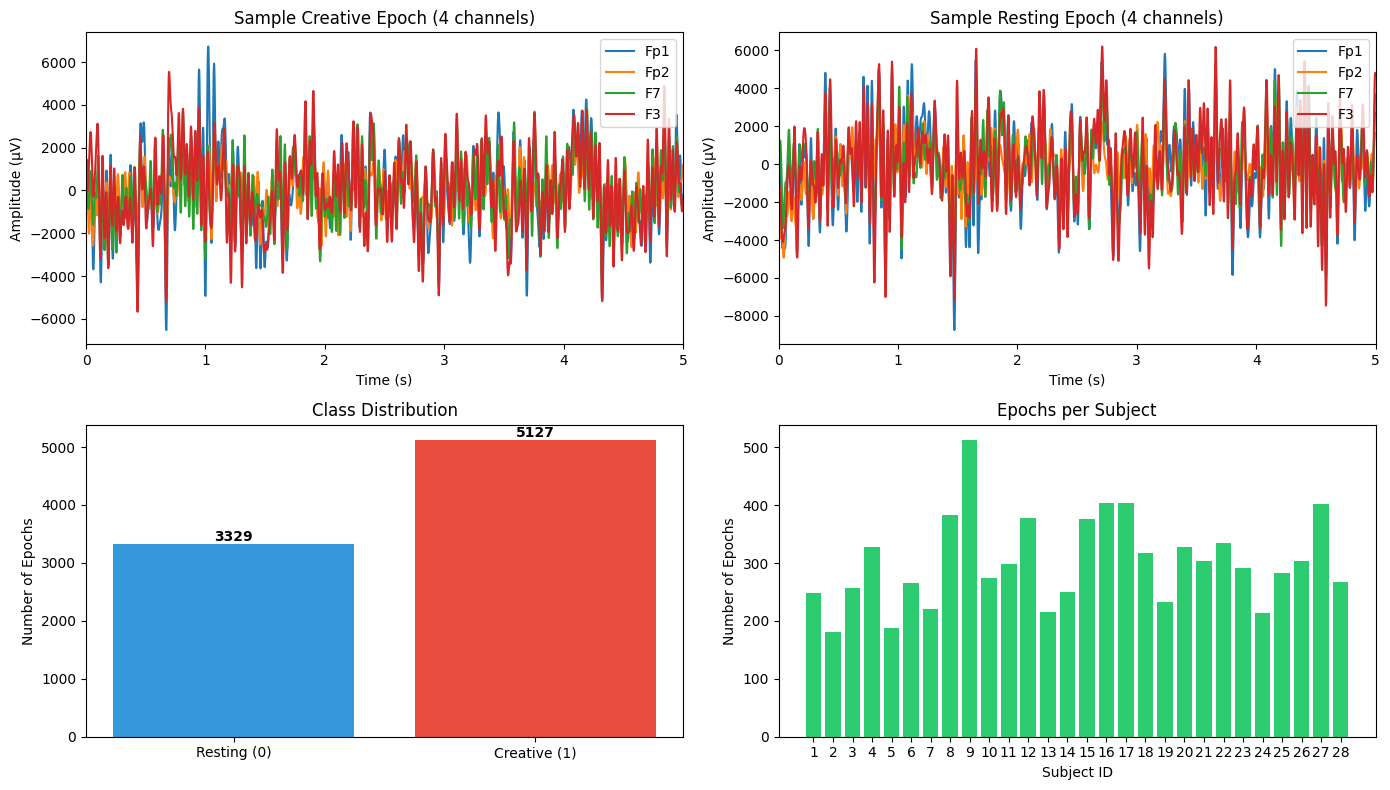


 Preprocessing selesai!
 Total: 8456 epochs dari 28 subjek
 File tersimpan di: /content/drive/MyDrive/Creativity-Dataset/processed_data/


In [ ]:
import numpy as np
import scipy.io as sio
from scipy import signal
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# ===========
# KONFIGURASI
# ===========

CONFIG = {
    'dataset_folder': '/content/drive/MyDrive/Creativity-Dataset',
    'output_folder': '/content/drive/MyDrive/Creativity-Dataset/processed_data',
    'sfreq': 500,
    'n_channels_original': 63,
    'lowcut': 0.5,
    'highcut': 50.0,
    'notch_freq': 50.0,
    'epoch_duration': 5.0,
    'overlap': 0.5,
    'selected_channels': {
        'Fp1': 0, 'Fp2': 1,
        'F7': 2, 'F3': 3, 'F4': 5, 'F8': 6,
        'C3': 12, 'C4': 14,
        'T7': 11, 'T8': 15,
        'P7': 22, 'P3': 23, 'P4': 25, 'P8': 26,
        'O1': 28, 'O2': 30
    }
}

CHANNEL_NAMES_16 = list(CONFIG['selected_channels'].keys())
CHANNEL_INDICES = list(CONFIG['selected_channels'].values())

print("=" * 60)
print("KONFIGURASI PREPROCESSING")
print("=" * 60)
print(f"Sampling Rate: {CONFIG['sfreq']} Hz")
print(f"Band-pass Filter: {CONFIG['lowcut']}-{CONFIG['highcut']} Hz")
print(f"Epoch Duration: {CONFIG['epoch_duration']}s, Overlap: {CONFIG['overlap']*100}%")
print(f"Selected Channels ({len(CHANNEL_NAMES_16)}): {CHANNEL_NAMES_16}")

# =====================
# FUNGSI PREPROCESSING
# =====================

def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype='band')
    return signal.filtfilt(b, a, data, axis=1)

def notch_filter(data, notch_freq, fs, quality=30):
    nyq = 0.5 * fs
    freq = notch_freq / nyq
    b, a = signal.iirnotch(freq, quality)
    return signal.filtfilt(b, a, data, axis=1)

def select_channels(data, channel_indices):
    return data[channel_indices, :]

def create_epochs(data, sfreq, epoch_duration, overlap):
    n_channels, n_samples = data.shape
    samples_per_epoch = int(epoch_duration * sfreq)
    step = int(samples_per_epoch * (1 - overlap))

    # Cek apakah data cukup panjang untuk minimal 1 epoch
    if n_samples < samples_per_epoch:
        return np.array([])  # Return empty array

    epochs = []
    start = 0
    while start + samples_per_epoch <= n_samples:
        epoch = data[:, start:start + samples_per_epoch]
        epochs.append(epoch)
        start += step

    if len(epochs) == 0:
        return np.array([])

    return np.array(epochs)

def preprocess_single_recording(data, config):
    # 1. Select channels
    data_16ch = select_channels(data, CHANNEL_INDICES)

    # 2. Band-pass filter
    data_filtered = butter_bandpass_filter(
        data_16ch, config['lowcut'], config['highcut'], config['sfreq']
    )

    # 3. Notch filter
    data_notched = notch_filter(
        data_filtered, config['notch_freq'], config['sfreq']
    )

    # 4. Create epochs
    epochs = create_epochs(
        data_notched, config['sfreq'], config['epoch_duration'], config['overlap']
    )

    return epochs

# ====================
# PROSES SEMUA SUBJEK
# ====================

def process_all_subjects(config):
    all_epochs_creative = []
    all_epochs_resting = []
    all_subject_ids_creative = []
    all_subject_ids_resting = []

    skipped_recordings = []  # Track skipped recordings

    mat_files = sorted([f for f in os.listdir(config['dataset_folder']) if f.endswith('.mat')])
    print(f"\nFound {len(mat_files)} subjects")

    for mat_file in tqdm(mat_files, desc="Processing subjects"):
        subject_id = int(mat_file.split('_')[-1].replace('.mat', ''))
        file_path = os.path.join(config['dataset_folder'], mat_file)
        mat_data = sio.loadmat(file_path)

        # Process Creative data (IDG + IDE + IDR)
        creative_keys = [k for k in mat_data.keys() if 'IDG' in k or 'IDE' in k or 'IDR' in k]
        for key in creative_keys:
            data = mat_data[key]
            if data.shape[0] == 63:
                epochs = preprocess_single_recording(data, config)
                # FIXED: Cek apakah epochs tidak kosong
                if epochs.size > 0 and len(epochs.shape) == 3:
                    all_epochs_creative.append(epochs)
                    all_subject_ids_creative.extend([subject_id] * len(epochs))
                else:
                    skipped_recordings.append(f"Sub_{subject_id}_{key} (too short)")

        # Process Resting data (RST1 + RST2)
        resting_keys = [k for k in mat_data.keys() if 'RST' in k]
        for key in resting_keys:
            data = mat_data[key]
            if data.shape[0] == 63:
                epochs = preprocess_single_recording(data, config)
                # FIXED: Cek apakah epochs tidak kosong
                if epochs.size > 0 and len(epochs.shape) == 3:
                    all_epochs_resting.append(epochs)
                    all_subject_ids_resting.extend([subject_id] * len(epochs))
                else:
                    skipped_recordings.append(f"Sub_{subject_id}_{key} (too short)")

    # Report skipped recordings
    if skipped_recordings:
        print(f"\n Skipped {len(skipped_recordings)} recordings (duration < {config['epoch_duration']}s):")
        for rec in skipped_recordings[:10]:  # Show first 10
            print(f"   - {rec}")
        if len(skipped_recordings) > 10:
            print(f"   ... and {len(skipped_recordings) - 10} more")

    # Concatenate all epochs
    X_creative = np.concatenate(all_epochs_creative, axis=0)
    X_resting = np.concatenate(all_epochs_resting, axis=0)

    y_creative = np.ones(len(X_creative))
    y_resting = np.zeros(len(X_resting))

    X = np.concatenate([X_creative, X_resting], axis=0)
    y = np.concatenate([y_creative, y_resting], axis=0)
    subject_ids = np.array(all_subject_ids_creative + all_subject_ids_resting)

    return X, y, subject_ids

# ======================
# JALANKAN PREPROCESSING
# ======================

print("\n" + "=" * 60)
print("MEMULAI PREPROCESSING")
print("=" * 60)

X, y, subject_ids = process_all_subjects(CONFIG)

print("\n" + "=" * 60)
print("HASIL PREPROCESSING")
print("=" * 60)
print(f"X shape: {X.shape}")
print(f"  - {X.shape[0]} epochs")
print(f"  - {X.shape[1]} channels")
print(f"  - {X.shape[2]} samples per epoch ({X.shape[2]/CONFIG['sfreq']}s)")
print(f"y shape: {y.shape}")
print(f"  - Creative (1): {int(np.sum(y == 1))}")
print(f"  - Resting (0): {int(np.sum(y == 0))}")
print(f"Subject IDs: {len(np.unique(subject_ids))} unique subjects")

# ===========
# SIMPAN DATA
# ===========

os.makedirs(CONFIG['output_folder'], exist_ok=True)

np.save(os.path.join(CONFIG['output_folder'], 'X_epochs.npy'), X)
np.save(os.path.join(CONFIG['output_folder'], 'y_labels.npy'), y)
np.save(os.path.join(CONFIG['output_folder'], 'subject_ids.npy'), subject_ids)
np.save(os.path.join(CONFIG['output_folder'], 'channel_names.npy'), CHANNEL_NAMES_16)

# Simpan juga config untuk referensi
import json
config_save = {k: v for k, v in CONFIG.items() if k != 'selected_channels'}
config_save['selected_channels'] = list(CONFIG['selected_channels'].keys())
with open(os.path.join(CONFIG['output_folder'], 'config.json'), 'w') as f:
    json.dump(config_save, f, indent=2)

print(f"\n Data tersimpan di folder: {CONFIG['output_folder']}/")

# ===========
# VISUALISASI
# ===========

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Sample Creative epoch
creative_idx = np.where(y == 1)[0][0]
ax1 = axes[0, 0]
time = np.arange(X.shape[2]) / CONFIG['sfreq']
for i in range(4):
    ax1.plot(time, X[creative_idx, i, :]*1e6 + i*20, label=CHANNEL_NAMES_16[i])
ax1.set_title('Sample Creative Epoch (4 channels)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude (µV)')
ax1.legend(loc='upper right')
ax1.set_xlim([0, 5])

# Sample Resting epoch
resting_idx = np.where(y == 0)[0][0]
ax2 = axes[0, 1]
for i in range(4):
    ax2.plot(time, X[resting_idx, i, :]*1e6 + i*20, label=CHANNEL_NAMES_16[i])
ax2.set_title('Sample Resting Epoch (4 channels)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude (µV)')
ax2.legend(loc='upper right')
ax2.set_xlim([0, 5])

# Class distribution
ax3 = axes[1, 0]
labels, counts = np.unique(y, return_counts=True)
bars = ax3.bar(['Resting (0)', 'Creative (1)'], counts, color=['#3498db', '#e74c3c'])
ax3.set_title('Class Distribution')
ax3.set_ylabel('Number of Epochs')
for bar, v in zip(bars, counts):
    ax3.text(bar.get_x() + bar.get_width()/2, v + 50, str(int(v)), ha='center', fontweight='bold')

# Epochs per subject
ax4 = axes[1, 1]
unique_subjects = np.unique(subject_ids)
epochs_per_subject = [np.sum(subject_ids == s) for s in unique_subjects]
ax4.bar(unique_subjects, epochs_per_subject, color='#2ecc71')
ax4.set_title('Epochs per Subject')
ax4.set_xlabel('Subject ID')
ax4.set_ylabel('Number of Epochs')
ax4.set_xticks(unique_subjects)

plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_folder'], 'preprocessing_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n Preprocessing selesai!")
print(f" Total: {X.shape[0]} epochs dari {len(np.unique(subject_ids))} subjek")
print(f" File tersimpan di: {CONFIG['output_folder']}/")

# FEATURE EXTRACTION ( DWT + Hjorth )

LOADING PREPROCESSED DATA
X shape: (8456, 16, 2500)
y shape: (8456,)
Channels: [np.str_('Fp1'), np.str_('Fp2'), np.str_('F7'), np.str_('F3'), np.str_('F4'), np.str_('F8'), np.str_('C3'), np.str_('C4'), np.str_('T7'), np.str_('T8'), np.str_('P7'), np.str_('P3'), np.str_('P4'), np.str_('P8'), np.str_('O1'), np.str_('O2')]

KONFIGURASI DWT
Wavelet: db4
Decomposition Level: 5
Bands: {'gamma': 'D3', 'beta': 'D4', 'alpha': 'D5', 'theta_delta': 'A5'}

EKSTRAKSI FITUR
Features per channel: 16
Total features: 256


Extracting features: 100%|██████████| 8456/8456 [01:30<00:00, 93.08it/s]



X_features shape: (8456, 256)
Feature names (first 10): ['Fp1_gamma_energy', 'Fp1_gamma_activity', 'Fp1_gamma_mobility', 'Fp1_gamma_complexity', 'Fp1_beta_energy', 'Fp1_beta_activity', 'Fp1_beta_mobility', 'Fp1_beta_complexity', 'Fp1_alpha_energy', 'Fp1_alpha_activity']
Feature names (last 10): ['O2_beta_mobility', 'O2_beta_complexity', 'O2_alpha_energy', 'O2_alpha_activity', 'O2_alpha_mobility', 'O2_alpha_complexity', 'O2_theta_delta_energy', 'O2_theta_delta_activity', 'O2_theta_delta_mobility', 'O2_theta_delta_complexity']

 Features tersimpan!
   - X_features.npy: (8456, 256)
   - feature_names.npy: 256 names


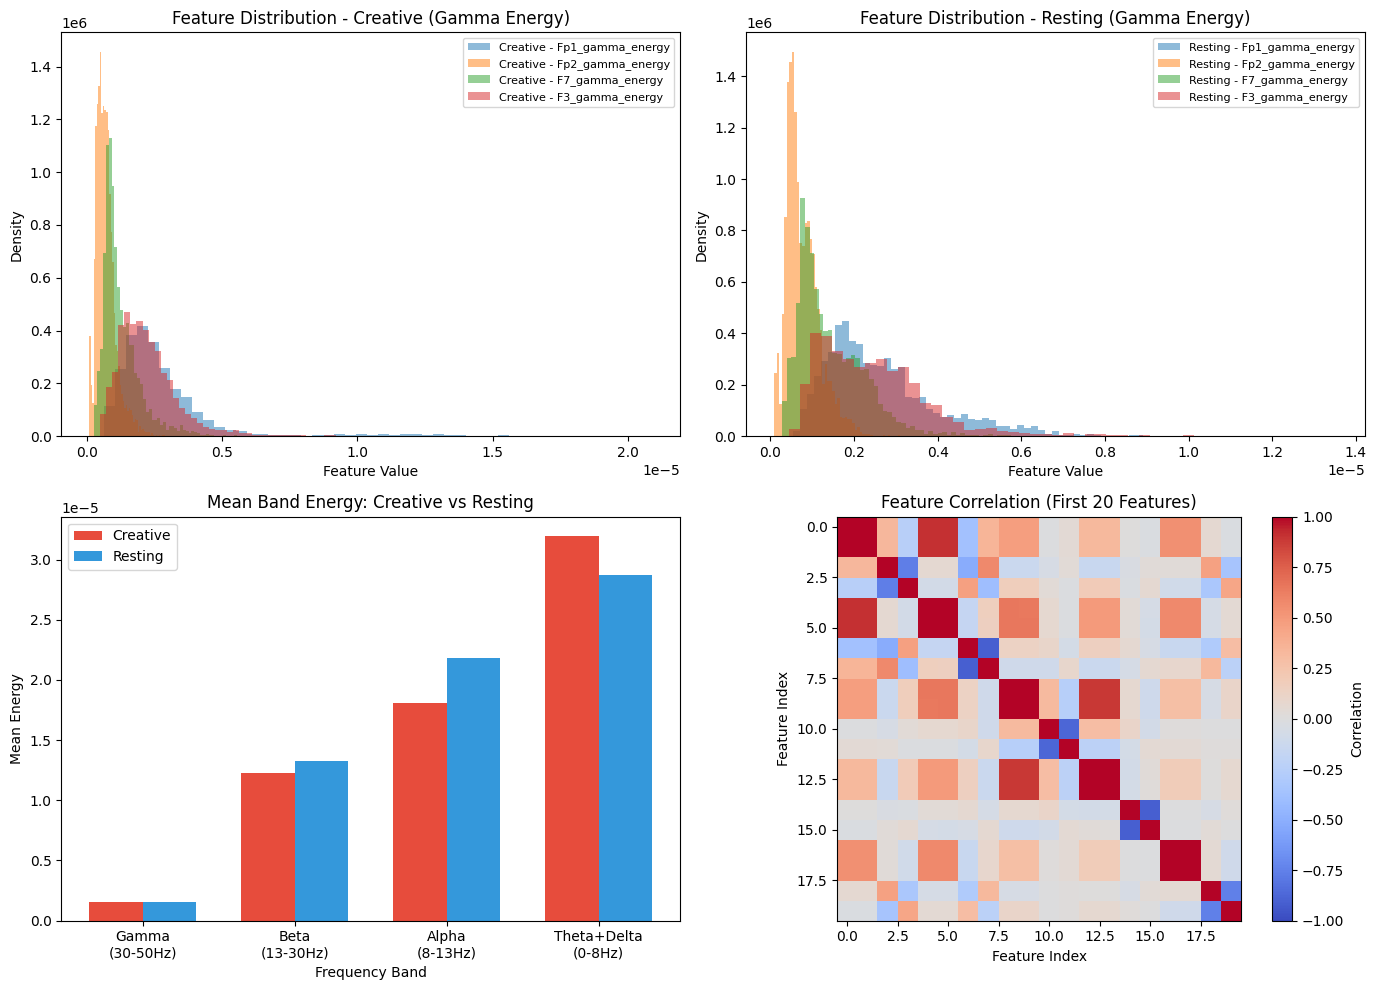


STATISTIK FITUR

Creative (n=5127):
  Mean: 0.680410
  Std:  0.710501

Resting (n=3329):
  Mean: 0.684010
  Std:  0.715268

Data Quality:
  NaN values: 0
  Inf values: 0

 Feature extraction selesai!


In [ ]:
import numpy as np
import pywt
from tqdm import tqdm
import os

# ======================
# LOAD DATA PREPROCESSED
# ======================

DATA_PATH = '/content/drive/MyDrive/Creativity-Dataset/processed_data'

print("=" * 60)
print("LOADING PREPROCESSED DATA")
print("=" * 60)

X = np.load(os.path.join(DATA_PATH, 'X_epochs.npy'))
y = np.load(os.path.join(DATA_PATH, 'y_labels.npy'))
subject_ids = np.load(os.path.join(DATA_PATH, 'subject_ids.npy'))
channel_names = np.load(os.path.join(DATA_PATH, 'channel_names.npy'))

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Channels: {list(channel_names)}")

# ===============
# KONFIGURASI DWT
# ===============

CONFIG = {
    'sfreq': 500,
    'wavelet': 'db4',  # Daubechies 4
    'level': 5,        # 5 level decomposition

    # Band frequency mapping untuk 500 Hz sampling rate
    # Level 1 (D1): 125-250 Hz -> Noise (tidak digunakan)
    # Level 2 (D2): 62.5-125 Hz -> High Gamma (tidak digunakan)
    # Level 3 (D3): 31.25-62.5 Hz -> Gamma (30-50 Hz)
    # Level 4 (D4): 15.625-31.25 Hz -> Beta (13-30 Hz)
    # Level 5 (D5): 7.8125-15.625 Hz -> Alpha (8-13 Hz)
    # Level 5 (A5): 0-7.8125 Hz -> Theta + Delta

    'bands': {
        'gamma': 'D3',   # ~30-50 Hz
        'beta': 'D4',    # ~13-30 Hz
        'alpha': 'D5',   # ~8-13 Hz
        'theta_delta': 'A5'  # ~0-8 Hz (combined)
    }
}

print("\n" + "=" * 60)
print("KONFIGURASI DWT")
print("=" * 60)
print(f"Wavelet: {CONFIG['wavelet']}")
print(f"Decomposition Level: {CONFIG['level']}")
print(f"Bands: {CONFIG['bands']}")

# ======================
# FUNGSI EKSTRAKSI FITUR
# ======================

def dwt_decompose(signal, wavelet='db4', level=5):
    """
    Decompose signal menggunakan DWT

    Returns:
        coeffs: list of coefficients [cA5, cD5, cD4, cD3, cD2, cD1]
    """
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    return coeffs

def hjorth_parameters(signal):
    """
    Menghitung Hjorth Parameters

    Returns:
        activity: variance of signal (power)
        mobility: sqrt(var(derivative) / var(signal))
        complexity: mobility(derivative) / mobility(signal)
    """
    # Activity = variance
    activity = np.var(signal)

    # First derivative
    diff1 = np.diff(signal)

    # Second derivative
    diff2 = np.diff(diff1)

    # Mobility
    if activity > 0:
        mobility = np.sqrt(np.var(diff1) / activity)
    else:
        mobility = 0

    # Complexity
    if np.var(diff1) > 0:
        mobility_diff1 = np.sqrt(np.var(diff2) / np.var(diff1))
        complexity = mobility_diff1 / mobility if mobility > 0 else 0
    else:
        complexity = 0

    return activity, mobility, complexity

def extract_band_energy(coeffs):
    """Extract energy dari setiap band DWT"""
    energies = {}
    band_names = ['A5', 'D5', 'D4', 'D3', 'D2', 'D1']

    for i, coeff in enumerate(coeffs):
        band = band_names[i]
        energies[band] = np.sum(coeff**2) / len(coeff)  # Normalized energy

    return energies

def extract_features_single_epoch(epoch, config):
    """
    Ekstraksi fitur dari satu epoch

    Parameters:
        epoch: (n_channels, n_samples)
        config: konfigurasi

    Returns:
        features: 1D array of features
    """
    n_channels = epoch.shape[0]
    all_features = []

    for ch in range(n_channels):
        signal = epoch[ch, :]

        # DWT Decomposition
        coeffs = dwt_decompose(signal, config['wavelet'], config['level'])

        # Band energies
        energies = extract_band_energy(coeffs)

        # Hjorth parameters untuk setiap band yang relevan
        band_coeffs = {
            'gamma': coeffs[3],    # D3
            'beta': coeffs[2],     # D4
            'alpha': coeffs[1],    # D5
            'theta_delta': coeffs[0]  # A5
        }

        # Extract features per band
        for band_name, band_coeff in band_coeffs.items():
            # Energy
            energy = np.sum(band_coeff**2) / len(band_coeff)
            all_features.append(energy)

            # Hjorth parameters
            activity, mobility, complexity = hjorth_parameters(band_coeff)
            all_features.extend([activity, mobility, complexity])

    return np.array(all_features)

# ================================
# EKSTRAKSI FITUR UNTUK SEMUA DATA
# ================================

print("\n" + "=" * 60)
print("EKSTRAKSI FITUR")
print("=" * 60)

# Hitung jumlah fitur
# Per channel: 4 bands × 4 features (energy + 3 Hjorth) = 16 features
# Total: 16 channels × 16 features = 256 features
n_features_per_channel = 4 * 4  # 4 bands × 4 features
n_total_features = len(channel_names) * n_features_per_channel

print(f"Features per channel: {n_features_per_channel}")
print(f"Total features: {n_total_features}")

# Extract features
X_features = []

for i in tqdm(range(len(X)), desc="Extracting features"):
    features = extract_features_single_epoch(X[i], CONFIG)
    X_features.append(features)

X_features = np.array(X_features)

print(f"\nX_features shape: {X_features.shape}")

# ===============
# BUAT NAMA FITUR
# ===============

feature_names = []
bands = ['gamma', 'beta', 'alpha', 'theta_delta']
hjorth_names = ['energy', 'activity', 'mobility', 'complexity']

for ch in channel_names:
    for band in bands:
        for hjorth in hjorth_names:
            feature_names.append(f"{ch}_{band}_{hjorth}")

print(f"Feature names (first 10): {feature_names[:10]}")
print(f"Feature names (last 10): {feature_names[-10:]}")

# ============
# SIMPAN FITUR
# ============

np.save(os.path.join(DATA_PATH, 'X_features.npy'), X_features)
np.save(os.path.join(DATA_PATH, 'feature_names.npy'), feature_names)

print(f"\n Features tersimpan!")
print(f"   - X_features.npy: {X_features.shape}")
print(f"   - feature_names.npy: {len(feature_names)} names")

# =================
# VISUALISASI FITUR
# =================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Feature distribution comparison (Creative vs Resting)
ax1 = axes[0, 0]
creative_mask = y == 1
resting_mask = y == 0

# Pilih beberapa fitur untuk visualisasi
sample_features = [0, 16, 32, 48]  # Fp1_gamma, Fp2_gamma, F7_gamma, F3_gamma
for idx in sample_features:
    ax1.hist(X_features[creative_mask, idx], bins=50, alpha=0.5,
             label=f'Creative - {feature_names[idx]}', density=True)
ax1.set_title('Feature Distribution - Creative (Gamma Energy)')
ax1.set_xlabel('Feature Value')
ax1.set_ylabel('Density')
ax1.legend(fontsize=8)

ax2 = axes[0, 1]
for idx in sample_features:
    ax2.hist(X_features[resting_mask, idx], bins=50, alpha=0.5,
             label=f'Resting - {feature_names[idx]}', density=True)
ax2.set_title('Feature Distribution - Resting (Gamma Energy)')
ax2.set_xlabel('Feature Value')
ax2.set_ylabel('Density')
ax2.legend(fontsize=8)

# 2. Mean feature comparison per band
ax3 = axes[1, 0]
bands_plot = ['gamma', 'beta', 'alpha', 'theta_delta']
x_pos = np.arange(len(bands_plot))
width = 0.35

creative_means = []
resting_means = []

for band in bands_plot:
    # Get all energy features for this band (first feature of each band per channel)
    band_indices = [i for i, name in enumerate(feature_names) if band in name and 'energy' in name]
    creative_means.append(np.mean(X_features[creative_mask][:, band_indices]))
    resting_means.append(np.mean(X_features[resting_mask][:, band_indices]))

bars1 = ax3.bar(x_pos - width/2, creative_means, width, label='Creative', color='#e74c3c')
bars2 = ax3.bar(x_pos + width/2, resting_means, width, label='Resting', color='#3498db')
ax3.set_title('Mean Band Energy: Creative vs Resting')
ax3.set_xlabel('Frequency Band')
ax3.set_ylabel('Mean Energy')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(['Gamma\n(30-50Hz)', 'Beta\n(13-30Hz)', 'Alpha\n(8-13Hz)', 'Theta+Delta\n(0-8Hz)'])
ax3.legend()

# 3. Correlation heatmap (sample)
ax4 = axes[1, 1]
# Use first 20 features for visualization
corr_matrix = np.corrcoef(X_features[:, :20].T)
im = ax4.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax4.set_title('Feature Correlation (First 20 Features)')
ax4.set_xlabel('Feature Index')
ax4.set_ylabel('Feature Index')
plt.colorbar(im, ax=ax4, label='Correlation')

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'feature_extraction_summary.png'), dpi=150, bbox_inches='tight')
plt.show()

# ===============
# STATISTIK FITUR
# ===============

print("\n" + "=" * 60)
print("STATISTIK FITUR")
print("=" * 60)

print(f"\nCreative (n={np.sum(creative_mask)}):")
print(f"  Mean: {np.mean(X_features[creative_mask]):.6f}")
print(f"  Std:  {np.std(X_features[creative_mask]):.6f}")

print(f"\nResting (n={np.sum(resting_mask)}):")
print(f"  Mean: {np.mean(X_features[resting_mask]):.6f}")
print(f"  Std:  {np.std(X_features[resting_mask]):.6f}")

# Check for NaN or Inf
print(f"\nData Quality:")
print(f"  NaN values: {np.sum(np.isnan(X_features))}")
print(f"  Inf values: {np.sum(np.isinf(X_features))}")

print("\n Feature extraction selesai!")

# KLASIFIKASI KNN

LOADING DATA
X_features shape: (8456, 256)
y shape: (8456,)
Subjects: 28
Class distribution: Creative=5127, Resting=3329

DATA SPLITTING
Training set: 5919 samples (70.0%)
Validation set: 1268 samples (15.0%)
Test set: 1269 samples (15.0%)

Class distribution:
  Train - Creative: 3589, Resting: 2330
  Val   - Creative: 769, Resting: 499
  Test  - Creative: 769, Resting: 500

FEATURE SCALING (StandardScaler)
Train - Mean: 0.0000, Std: 1.0000
Val   - Mean: 0.0028, Std: 1.0071
Test  - Mean: -0.0048, Std: 0.9826

HYPERPARAMETER TUNING (GridSearchCV)
Fitting 5 folds for each of 42 candidates, totalling 210 fits

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Best CV F1 Score: 0.9656

VALIDATION SET EVALUATION
Accuracy:  0.9732
Precision: 0.9670
Recall:    0.9896
F1-Score:  0.9781
AUC-ROC:   0.9903

TEST SET EVALUATION (Final)
Accuracy:  0.9685
Precision: 0.9632
Recall:    0.9857
F1-Score:  0.9743
AUC-ROC:   0.9906

Classification Report:
              preci

LOSO Validation: 100%|██████████| 28/28 [00:23<00:00,  1.17it/s]



LOSO Results (28 subjects):
  Accuracy:  0.7660 ± 0.1222
  Precision: 0.7879 ± 0.1177
  Recall:    0.8638 ± 0.1702
  F1-Score:  0.8060 ± 0.1075


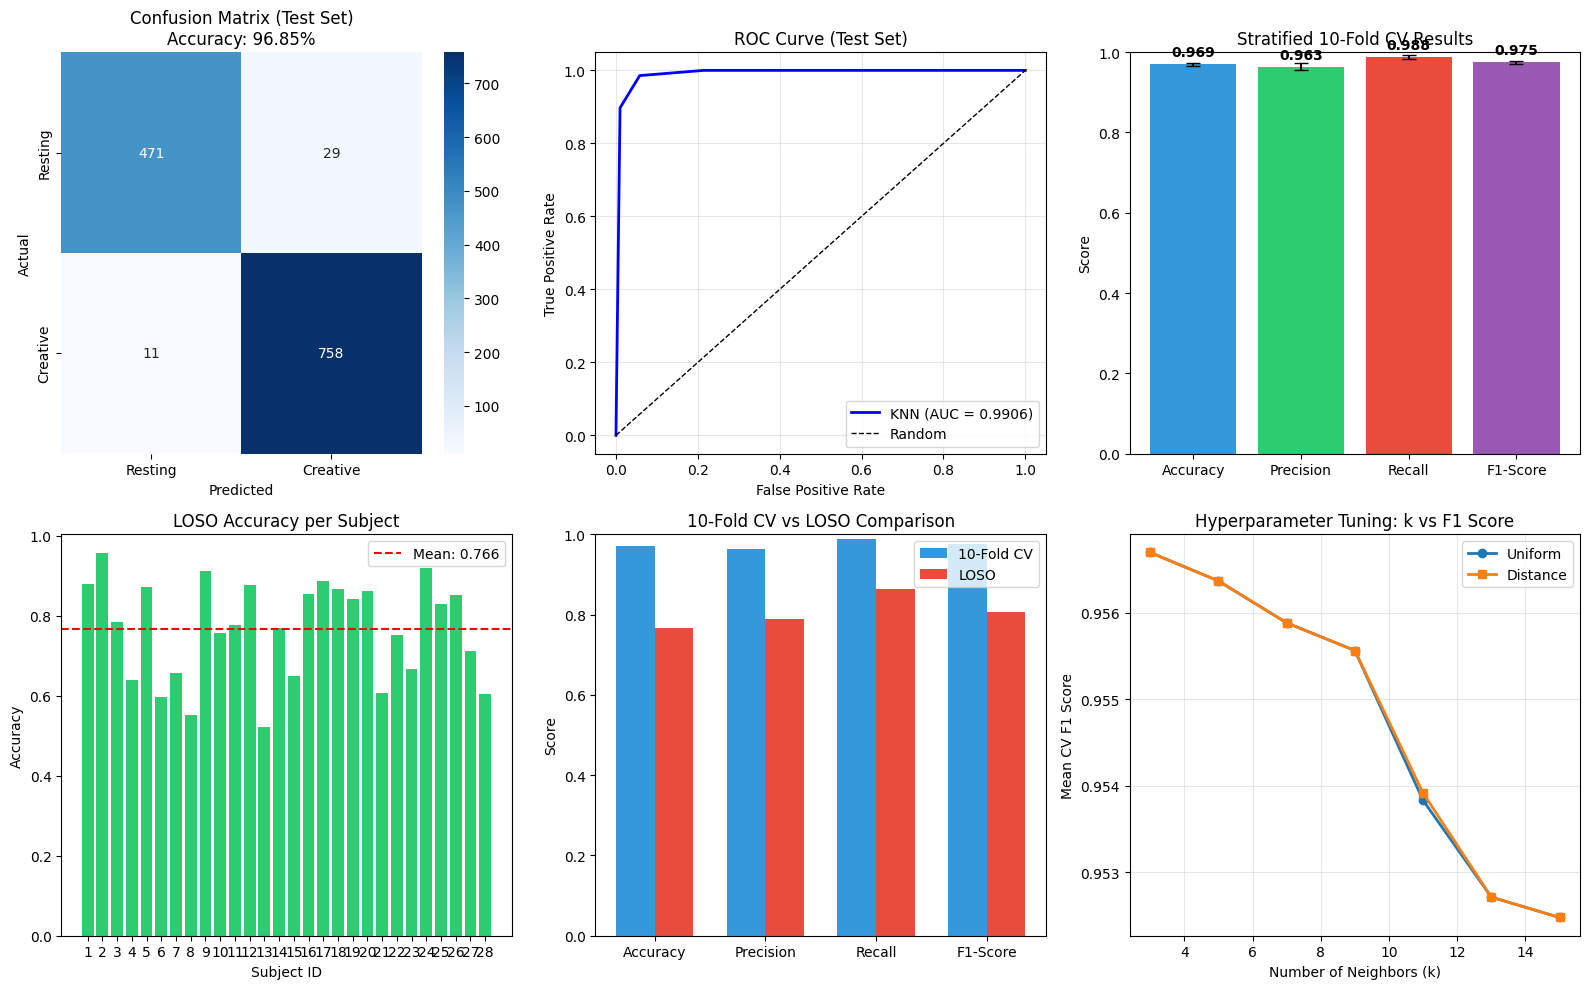


RINGKASAN HASIL KLASIFIKASI

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}

 Test Set Performance:
   Accuracy:  0.9685 (96.85%)
   Precision: 0.9632
   Recall:    0.9857
   F1-Score:  0.9743
   AUC-ROC:   0.9906

 10-Fold CV:
   Accuracy:  0.9695 ± 0.0046
   F1-Score:  0.9752 ± 0.0037

 LOSO Validation:
   Accuracy:  0.7660 ± 0.1222
   F1-Score:  0.8060 ± 0.1075

 Model dan hasil tersimpan di: /content/drive/MyDrive/Creativity-Dataset/processed_data/


In [ ]:
import numpy as np
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, confusion_matrix, classification_report,
                            roc_curve, auc, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# =========
# LOAD DATA
# =========

DATA_PATH = '/content/drive/MyDrive/Creativity-Dataset/processed_data'

print("=" * 60)
print("LOADING DATA")
print("=" * 60)

X_features = np.load(os.path.join(DATA_PATH, 'X_features.npy'))
y = np.load(os.path.join(DATA_PATH, 'y_labels.npy'))
subject_ids = np.load(os.path.join(DATA_PATH, 'subject_ids.npy'))
feature_names = np.load(os.path.join(DATA_PATH, 'feature_names.npy'))

print(f"X_features shape: {X_features.shape}")
print(f"y shape: {y.shape}")
print(f"Subjects: {len(np.unique(subject_ids))}")
print(f"Class distribution: Creative={np.sum(y==1)}, Resting={np.sum(y==0)}")

# ===============================
# TRAIN/VAL/TEST SPLIT (70/15/15)
# ===============================

print("\n" + "=" * 60)
print("DATA SPLITTING")
print("=" * 60)

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp, subj_train, subj_temp = train_test_split(
    X_features, y, subject_ids,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: 50% of temp = 15% validation, 15% test
X_val, X_test, y_val, y_test, subj_val, subj_test = train_test_split(
    X_temp, y_temp, subj_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(y)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(y)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/len(y)*100:.1f}%)")

print(f"\nClass distribution:")
print(f"  Train - Creative: {np.sum(y_train==1)}, Resting: {np.sum(y_train==0)}")
print(f"  Val   - Creative: {np.sum(y_val==1)}, Resting: {np.sum(y_val==0)}")
print(f"  Test  - Creative: {np.sum(y_test==1)}, Resting: {np.sum(y_test==0)}")

# ===============
# FEATURE SCALING
# ===============

print("\n" + "=" * 60)
print("FEATURE SCALING (StandardScaler)")
print("=" * 60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"Val   - Mean: {X_val_scaled.mean():.4f}, Std: {X_val_scaled.std():.4f}")
print(f"Test  - Mean: {X_test_scaled.mean():.4f}, Std: {X_test_scaled.std():.4f}")

# =========================================
# HYPERPARAMETER TUNING dengan GridSearchCV
# =========================================

print("\n" + "=" * 60)
print("HYPERPARAMETER TUNING (GridSearchCV)")
print("=" * 60)

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV F1 Score: {grid_search.best_score_:.4f}")

best_knn = grid_search.best_estimator_

# ============================
# EVALUASI PADA VALIDATION SET
# ============================

print("\n" + "=" * 60)
print("VALIDATION SET EVALUATION")
print("=" * 60)

y_val_pred = best_knn.predict(X_val_scaled)
y_val_proba = best_knn.predict_proba(X_val_scaled)[:, 1]

val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_auc = roc_auc_score(y_val, y_val_proba)

print(f"Accuracy:  {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall:    {val_recall:.4f}")
print(f"F1-Score:  {val_f1:.4f}")
print(f"AUC-ROC:   {val_auc:.4f}")

# ======================
# EVALUASI PADA TEST SET
# ======================

print("\n" + "=" * 60)
print("TEST SET EVALUATION (Final)")
print("=" * 60)

y_test_pred = best_knn.predict(X_test_scaled)
y_test_proba = best_knn.predict_proba(X_test_scaled)[:, 1]

test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)

print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"AUC-ROC:   {test_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Resting', 'Creative']))

# ===================================
# STRATIFIED 10-FOLD CROSS-VALIDATION
# ===================================

print("\n" + "=" * 60)
print("STRATIFIED 10-FOLD CROSS-VALIDATION")
print("=" * 60)

# Scale all data
X_all_scaled = scaler.fit_transform(X_features)

cv_10fold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_scores = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': []
}

for fold, (train_idx, test_idx) in enumerate(cv_10fold.split(X_all_scaled, y)):
    X_fold_train, X_fold_test = X_all_scaled[train_idx], X_all_scaled[test_idx]
    y_fold_train, y_fold_test = y[train_idx], y[test_idx]

    knn_fold = KNeighborsClassifier(**grid_search.best_params_)
    knn_fold.fit(X_fold_train, y_fold_train)
    y_fold_pred = knn_fold.predict(X_fold_test)

    cv_scores['accuracy'].append(accuracy_score(y_fold_test, y_fold_pred))
    cv_scores['precision'].append(precision_score(y_fold_test, y_fold_pred))
    cv_scores['recall'].append(recall_score(y_fold_test, y_fold_pred))
    cv_scores['f1'].append(f1_score(y_fold_test, y_fold_pred))

print(f"10-Fold CV Results:")
print(f"  Accuracy:  {np.mean(cv_scores['accuracy']):.4f} ± {np.std(cv_scores['accuracy']):.4f}")
print(f"  Precision: {np.mean(cv_scores['precision']):.4f} ± {np.std(cv_scores['precision']):.4f}")
print(f"  Recall:    {np.mean(cv_scores['recall']):.4f} ± {np.std(cv_scores['recall']):.4f}")
print(f"  F1-Score:  {np.mean(cv_scores['f1']):.4f} ± {np.std(cv_scores['f1']):.4f}")

# =======================================
# LEAVE-ONE-SUBJECT-OUT (LOSO) VALIDATION
# =======================================

print("\n" + "=" * 60)
print("LEAVE-ONE-SUBJECT-OUT (LOSO) VALIDATION")
print("=" * 60)

unique_subjects = np.unique(subject_ids)
loso_scores = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'subject': []
}

for subj in tqdm(unique_subjects, desc="LOSO Validation"):
    # Split data
    test_mask = subject_ids == subj
    train_mask = ~test_mask

    X_loso_train = X_features[train_mask]
    X_loso_test = X_features[test_mask]
    y_loso_train = y[train_mask]
    y_loso_test = y[test_mask]

    # Scale
    scaler_loso = StandardScaler()
    X_loso_train_scaled = scaler_loso.fit_transform(X_loso_train)
    X_loso_test_scaled = scaler_loso.transform(X_loso_test)

    # Train and predict
    knn_loso = KNeighborsClassifier(**grid_search.best_params_)
    knn_loso.fit(X_loso_train_scaled, y_loso_train)
    y_loso_pred = knn_loso.predict(X_loso_test_scaled)

    # Metrics
    loso_scores['accuracy'].append(accuracy_score(y_loso_test, y_loso_pred))
    loso_scores['precision'].append(precision_score(y_loso_test, y_loso_pred, zero_division=0))
    loso_scores['recall'].append(recall_score(y_loso_test, y_loso_pred, zero_division=0))
    loso_scores['f1'].append(f1_score(y_loso_test, y_loso_pred, zero_division=0))
    loso_scores['subject'].append(subj)

print(f"\nLOSO Results ({len(unique_subjects)} subjects):")
print(f"  Accuracy:  {np.mean(loso_scores['accuracy']):.4f} ± {np.std(loso_scores['accuracy']):.4f}")
print(f"  Precision: {np.mean(loso_scores['precision']):.4f} ± {np.std(loso_scores['precision']):.4f}")
print(f"  Recall:    {np.mean(loso_scores['recall']):.4f} ± {np.std(loso_scores['recall']):.4f}")
print(f"  F1-Score:  {np.mean(loso_scores['f1']):.4f} ± {np.std(loso_scores['f1']):.4f}")

# =================
# VISUALISASI HASIL
# =================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Confusion Matrix (Test Set)
ax1 = axes[0, 0]
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=['Resting', 'Creative'],
            yticklabels=['Resting', 'Creative'])
ax1.set_title(f'Confusion Matrix (Test Set)\nAccuracy: {test_accuracy:.2%}')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

# 2. ROC Curve
ax2 = axes[0, 1]
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
ax2.plot(fpr, tpr, 'b-', linewidth=2, label=f'KNN (AUC = {test_auc:.4f})')
ax2.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve (Test Set)')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3)

# 3. 10-Fold CV Scores
ax3 = axes[0, 2]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
means = [np.mean(cv_scores['accuracy']), np.mean(cv_scores['precision']),
         np.mean(cv_scores['recall']), np.mean(cv_scores['f1'])]
stds = [np.std(cv_scores['accuracy']), np.std(cv_scores['precision']),
        np.std(cv_scores['recall']), np.std(cv_scores['f1'])]
bars = ax3.bar(metrics, means, yerr=stds, capsize=5, color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
ax3.set_title('Stratified 10-Fold CV Results')
ax3.set_ylabel('Score')
ax3.set_ylim([0, 1])
for bar, mean in zip(bars, means):
    ax3.text(bar.get_x() + bar.get_width()/2, mean + 0.02, f'{mean:.3f}',
             ha='center', fontweight='bold')

# 4. LOSO Accuracy per Subject
ax4 = axes[1, 0]
ax4.bar(loso_scores['subject'], loso_scores['accuracy'], color='#2ecc71')
ax4.axhline(y=np.mean(loso_scores['accuracy']), color='red', linestyle='--',
            label=f'Mean: {np.mean(loso_scores["accuracy"]):.3f}')
ax4.set_xlabel('Subject ID')
ax4.set_ylabel('Accuracy')
ax4.set_title('LOSO Accuracy per Subject')
ax4.legend()
ax4.set_xticks(unique_subjects)

# 5. Comparison: 10-Fold vs LOSO
ax5 = axes[1, 1]
x_pos = np.arange(4)
width = 0.35
cv_means = [np.mean(cv_scores['accuracy']), np.mean(cv_scores['precision']),
            np.mean(cv_scores['recall']), np.mean(cv_scores['f1'])]
loso_means = [np.mean(loso_scores['accuracy']), np.mean(loso_scores['precision']),
              np.mean(loso_scores['recall']), np.mean(loso_scores['f1'])]
bars1 = ax5.bar(x_pos - width/2, cv_means, width, label='10-Fold CV', color='#3498db')
bars2 = ax5.bar(x_pos + width/2, loso_means, width, label='LOSO', color='#e74c3c')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(metrics)
ax5.set_ylabel('Score')
ax5.set_title('10-Fold CV vs LOSO Comparison')
ax5.legend()
ax5.set_ylim([0, 1])

# 6. Hyperparameter Tuning Results
ax6 = axes[1, 2]
results_df = grid_search.cv_results_
k_values = [3, 5, 7, 9, 11, 13, 15]
uniform_scores = []
distance_scores = []
for k in k_values:
    mask_uniform = (results_df['param_n_neighbors'] == k) & (results_df['param_weights'] == 'uniform')
    mask_distance = (results_df['param_n_neighbors'] == k) & (results_df['param_weights'] == 'distance')
    uniform_scores.append(np.mean(results_df['mean_test_score'][mask_uniform]))
    distance_scores.append(np.mean(results_df['mean_test_score'][mask_distance]))
ax6.plot(k_values, uniform_scores, 'o-', label='Uniform', linewidth=2)
ax6.plot(k_values, distance_scores, 's-', label='Distance', linewidth=2)
ax6.set_xlabel('Number of Neighbors (k)')
ax6.set_ylabel('Mean CV F1 Score')
ax6.set_title('Hyperparameter Tuning: k vs F1 Score')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'classification_results.png'), dpi=150, bbox_inches='tight')
plt.show()

# ======================
# SIMPAN MODEL DAN HASIL
# ======================

import joblib

# Save model
joblib.dump(best_knn, os.path.join(DATA_PATH, 'knn_model.joblib'))
joblib.dump(scaler, os.path.join(DATA_PATH, 'scaler.joblib'))

# Save results
results = {
    'best_params': grid_search.best_params_,
    'test_accuracy': test_accuracy,
    'test_precision': test_precision,
    'test_recall': test_recall,
    'test_f1': test_f1,
    'test_auc': test_auc,
    'cv_10fold_accuracy_mean': np.mean(cv_scores['accuracy']),
    'cv_10fold_accuracy_std': np.std(cv_scores['accuracy']),
    'cv_10fold_f1_mean': np.mean(cv_scores['f1']),
    'cv_10fold_f1_std': np.std(cv_scores['f1']),
    'loso_accuracy_mean': np.mean(loso_scores['accuracy']),
    'loso_accuracy_std': np.std(loso_scores['accuracy']),
    'loso_f1_mean': np.mean(loso_scores['f1']),
    'loso_f1_std': np.std(loso_scores['f1'])
}

np.save(os.path.join(DATA_PATH, 'classification_results.npy'), results)

print("\n" + "=" * 60)
print("RINGKASAN HASIL KLASIFIKASI")
print("=" * 60)
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"\n Test Set Performance:")
print(f"   Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall:    {test_recall:.4f}")
print(f"   F1-Score:  {test_f1:.4f}")
print(f"   AUC-ROC:   {test_auc:.4f}")
print(f"\n 10-Fold CV:")
print(f"   Accuracy:  {np.mean(cv_scores['accuracy']):.4f} ± {np.std(cv_scores['accuracy']):.4f}")
print(f"   F1-Score:  {np.mean(cv_scores['f1']):.4f} ± {np.std(cv_scores['f1']):.4f}")
print(f"\n LOSO Validation:")
print(f"   Accuracy:  {np.mean(loso_scores['accuracy']):.4f} ± {np.std(loso_scores['accuracy']):.4f}")
print(f"   F1-Score:  {np.mean(loso_scores['f1']):.4f} ± {np.std(loso_scores['f1']):.4f}")

print(f"\n Model dan hasil tersimpan di: {DATA_PATH}/")

# ANALISIS STATISTIK

LOADING DATA
X_features shape: (8456, 256)
Creative samples: 5127
Resting samples: 3329
Number of features: 256

UJI STATISTIK UNTUK SEMUA FITUR


Statistical tests: 100%|██████████| 256/256 [00:00<00:00, 356.33it/s]



Bonferroni corrected alpha: 0.000195

RINGKASAN HASIL STATISTIK

Total features: 256
Significant (p < 0.05): 240 (93.8%)
Significant (Bonferroni): 229 (89.5%)

Effect Size Distribution:
  Small: 111 (43.4%)
  Negligible: 100 (39.1%)
  Medium: 27 (10.5%)
  Large: 18 (7.0%)

TOP 20 FITUR PALING DISKRIMINATIF

Feature                                     Cohen's d  Effect Size    p-value    Direction
------------------------------------------------------------------------------------------
T8_alpha_complexity                            1.4713        Large   0.00e+00   Creative >
T8_beta_complexity                             1.4201        Large   0.00e+00   Creative >
T8_alpha_mobility                             -1.4151        Large   0.00e+00    Resting >
T8_gamma_mobility                              1.3506        Large   0.00e+00   Creative >
T8_beta_mobility                              -1.3144        Large   0.00e+00    Resting >
C4_beta_complexity                             1.1952

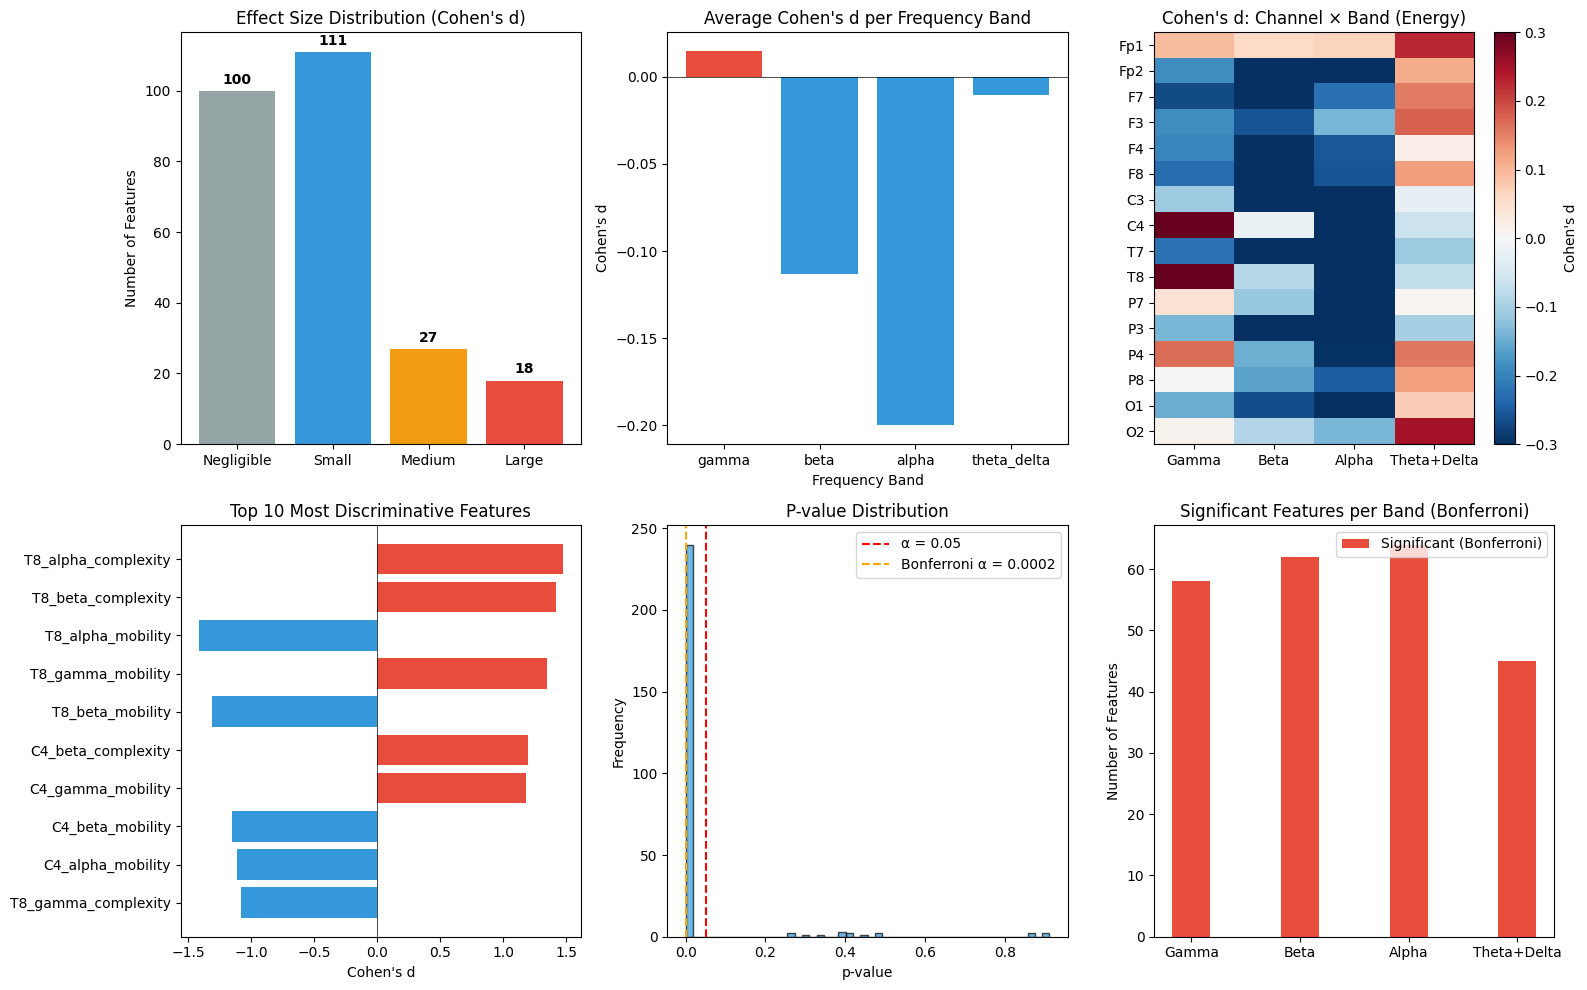


 Hasil statistik tersimpan di: /content/drive/MyDrive/Creativity-Dataset/processed_data/
   - statistical_results.csv
   - statistical_analysis.png

RINGKASAN UNTUK ABSTRAK/HASIL PENELITIAN

 Fitur Paling Diskriminatif:
   T8_alpha_complexity
   Cohen's d = 1.4713 (Large)
   p-value = 0.00e+00

 Temuan per Band:
   GAMMA: Cohen's d = 0.0147 (Creative > Resting)
   BETA: Cohen's d = -0.1129 (Resting > Creative)
   ALPHA: Cohen's d = -0.2000 (Resting > Creative)
   THETA_DELTA: Cohen's d = -0.0102 (Resting > Creative)

 Signifikansi Statistik:
   - 229/256 fitur signifikan (Bonferroni corrected)
   - Effect size: Large=18, Medium=27, Small=111


In [ ]:
import numpy as np
import os
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# =========
# LOAD DATA
# =========

DATA_PATH = '/content/drive/MyDrive/Creativity-Dataset/processed_data'

print("=" * 60)
print("LOADING DATA")
print("=" * 60)

X_features = np.load(os.path.join(DATA_PATH, 'X_features.npy'))
y = np.load(os.path.join(DATA_PATH, 'y_labels.npy'))
feature_names = np.load(os.path.join(DATA_PATH, 'feature_names.npy'))

creative_mask = y == 1
resting_mask = y == 0

print(f"X_features shape: {X_features.shape}")
print(f"Creative samples: {np.sum(creative_mask)}")
print(f"Resting samples: {np.sum(resting_mask)}")
print(f"Number of features: {len(feature_names)}")

# ================
# FUNGSI STATISTIK
# ================

def cohens_d(group1, group2):
    """Calculate Cohen's d effect size"""
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)

    # Pooled standard deviation
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))

    if pooled_std == 0:
        return 0

    return (np.mean(group1) - np.mean(group2)) / pooled_std

def interpret_cohens_d(d):
    """Interpret Cohen's d effect size"""
    d = abs(d)
    if d < 0.2:
        return "Negligible"
    elif d < 0.5:
        return "Small"
    elif d < 0.8:
        return "Medium"
    else:
        return "Large"

def check_normality(data, alpha=0.05):
    """Check normality using Shapiro-Wilk test (sample)"""
    # Use sample if data too large
    if len(data) > 5000:
        sample = np.random.choice(data, 5000, replace=False)
    else:
        sample = data
    stat, p = shapiro(sample)
    return p > alpha

# ===============================
# UJI STATISTIK UNTUK SEMUA FITUR
# ===============================

print("\n" + "=" * 60)
print("UJI STATISTIK UNTUK SEMUA FITUR")
print("=" * 60)

results = []

for i, feature_name in enumerate(tqdm(feature_names, desc="Statistical tests")):
    creative_data = X_features[creative_mask, i]
    resting_data = X_features[resting_mask, i]

    # Descriptive statistics
    creative_mean = np.mean(creative_data)
    creative_std = np.std(creative_data)
    resting_mean = np.mean(resting_data)
    resting_std = np.std(resting_data)

    # Check normality (sample)
    is_normal_creative = check_normality(creative_data)
    is_normal_resting = check_normality(resting_data)
    is_normal = is_normal_creative and is_normal_resting

    # Statistical test
    if is_normal:
        # Independent t-test
        stat, p_value = ttest_ind(creative_data, resting_data)
        test_used = "t-test"
    else:
        # Mann-Whitney U test
        stat, p_value = mannwhitneyu(creative_data, resting_data, alternative='two-sided')
        test_used = "Mann-Whitney U"

    # Effect size (Cohen's d)
    effect_size = cohens_d(creative_data, resting_data)
    effect_interpretation = interpret_cohens_d(effect_size)

    results.append({
        'feature': feature_name,
        'creative_mean': creative_mean,
        'creative_std': creative_std,
        'resting_mean': resting_mean,
        'resting_std': resting_std,
        'test': test_used,
        'statistic': stat,
        'p_value': p_value,
        'cohens_d': effect_size,
        'effect_size': effect_interpretation,
        'significant': p_value < 0.05
    })

# Create DataFrame
df_results = pd.DataFrame(results)

# Bonferroni correction
alpha = 0.05
bonferroni_alpha = alpha / len(feature_names)
df_results['significant_bonferroni'] = df_results['p_value'] < bonferroni_alpha

print(f"\nBonferroni corrected alpha: {bonferroni_alpha:.6f}")

# ===============
# RINGKASAN HASIL
# ===============

print("\n" + "=" * 60)
print("RINGKASAN HASIL STATISTIK")
print("=" * 60)

n_significant = df_results['significant'].sum()
n_significant_bonf = df_results['significant_bonferroni'].sum()

print(f"\nTotal features: {len(feature_names)}")
print(f"Significant (p < 0.05): {n_significant} ({n_significant/len(feature_names)*100:.1f}%)")
print(f"Significant (Bonferroni): {n_significant_bonf} ({n_significant_bonf/len(feature_names)*100:.1f}%)")

# Effect size distribution
effect_counts = df_results['effect_size'].value_counts()
print(f"\nEffect Size Distribution:")
for effect, count in effect_counts.items():
    print(f"  {effect}: {count} ({count/len(feature_names)*100:.1f}%)")

# ==============================
# TOP 20 FITUR PALING SIGNIFIKAN
# ==============================

print("\n" + "=" * 60)
print("TOP 20 FITUR PALING DISKRIMINATIF")
print("=" * 60)

# Sort by absolute Cohen's d
df_results['abs_cohens_d'] = df_results['cohens_d'].abs()
df_top20 = df_results.nlargest(20, 'abs_cohens_d')

print("\n{:<40} {:>12} {:>12} {:>10} {:>12}".format(
    "Feature", "Cohen's d", "Effect Size", "p-value", "Direction"))
print("-" * 90)

for _, row in df_top20.iterrows():
    direction = "Creative >" if row['cohens_d'] > 0 else "Resting >"
    print("{:<40} {:>12.4f} {:>12} {:>10.2e} {:>12}".format(
        row['feature'], row['cohens_d'], row['effect_size'],
        row['p_value'], direction))

# ===========================
# ANALISIS PER BAND FREKUENSI
# ===========================

print("\n" + "=" * 60)
print("ANALISIS PER BAND FREKUENSI")
print("=" * 60)

bands = ['gamma', 'beta', 'alpha', 'theta_delta']
band_stats = []

for band in bands:
    band_features = df_results[df_results['feature'].str.contains(band)]

    avg_cohens_d = band_features['cohens_d'].mean()
    avg_p_value = band_features['p_value'].mean()
    n_significant = band_features['significant_bonferroni'].sum()

    # Direction analysis
    positive = (band_features['cohens_d'] > 0).sum()
    negative = (band_features['cohens_d'] < 0).sum()

    band_stats.append({
        'band': band,
        'avg_cohens_d': avg_cohens_d,
        'avg_p_value': avg_p_value,
        'n_significant': n_significant,
        'creative_higher': positive,
        'resting_higher': negative
    })

    print(f"\n{band.upper()}:")
    print(f"  Average Cohen's d: {avg_cohens_d:.4f}")
    print(f"  Significant features (Bonferroni): {n_significant}/{len(band_features)}")
    print(f"  Creative > Resting: {positive}, Resting > Creative: {negative}")

# ====================
# ANALISIS PER CHANNEL
# ====================

print("\n" + "=" * 60)
print("ANALISIS PER CHANNEL")
print("=" * 60)

channels = ['Fp1', 'Fp2', 'F7', 'F3', 'F4', 'F8', 'C3', 'C4',
            'T7', 'T8', 'P7', 'P3', 'P4', 'P8', 'O1', 'O2']

channel_stats = []
for ch in channels:
    ch_features = df_results[df_results['feature'].str.startswith(ch + '_')]

    avg_cohens_d = ch_features['cohens_d'].mean()
    n_significant = ch_features['significant_bonferroni'].sum()

    channel_stats.append({
        'channel': ch,
        'avg_cohens_d': avg_cohens_d,
        'n_significant': n_significant
    })

df_channel_stats = pd.DataFrame(channel_stats)
df_channel_stats = df_channel_stats.sort_values('avg_cohens_d', key=abs, ascending=False)

print("\n{:<10} {:>15} {:>15}".format("Channel", "Avg Cohen's d", "N Significant"))
print("-" * 45)
for _, row in df_channel_stats.iterrows():
    print("{:<10} {:>15.4f} {:>15}".format(
        row['channel'], row['avg_cohens_d'], row['n_significant']))

# ===========
# VISUALISASI
# ===========

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Effect Size Distribution
ax1 = axes[0, 0]
effect_order = ['Negligible', 'Small', 'Medium', 'Large']
effect_colors = ['#95a5a6', '#3498db', '#f39c12', '#e74c3c']
counts = [effect_counts.get(e, 0) for e in effect_order]
bars = ax1.bar(effect_order, counts, color=effect_colors)
ax1.set_title('Effect Size Distribution (Cohen\'s d)')
ax1.set_ylabel('Number of Features')
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, count + 2, str(count),
             ha='center', fontweight='bold')

# 2. Cohen's d per Band
ax2 = axes[0, 1]
df_band_stats = pd.DataFrame(band_stats)
colors = ['#e74c3c' if d > 0 else '#3498db' for d in df_band_stats['avg_cohens_d']]
bars = ax2.bar(df_band_stats['band'], df_band_stats['avg_cohens_d'], color=colors)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_title('Average Cohen\'s d per Frequency Band')
ax2.set_ylabel('Cohen\'s d')
ax2.set_xlabel('Frequency Band')

# 3. Heatmap: Channel x Band Cohen's d
ax3 = axes[0, 2]
heatmap_data = np.zeros((len(channels), len(bands)))
for i, ch in enumerate(channels):
    for j, band in enumerate(bands):
        feature_name = f"{ch}_{band}_energy"
        if feature_name in df_results['feature'].values:
            heatmap_data[i, j] = df_results[df_results['feature'] == feature_name]['cohens_d'].values[0]

im = ax3.imshow(heatmap_data, cmap='RdBu_r', aspect='auto', vmin=-0.3, vmax=0.3)
ax3.set_xticks(range(len(bands)))
ax3.set_xticklabels(['Gamma', 'Beta', 'Alpha', 'Theta+Delta'])
ax3.set_yticks(range(len(channels)))
ax3.set_yticklabels(channels)
ax3.set_title('Cohen\'s d: Channel × Band (Energy)')
plt.colorbar(im, ax=ax3, label="Cohen's d")

# 4. Top 10 Features by |Cohen's d|
ax4 = axes[1, 0]
top10 = df_top20.head(10)
colors = ['#e74c3c' if d > 0 else '#3498db' for d in top10['cohens_d']]
ax4.barh(range(10), top10['cohens_d'], color=colors)
ax4.set_yticks(range(10))
ax4.set_yticklabels(top10['feature'])
ax4.set_xlabel("Cohen's d")
ax4.set_title('Top 10 Most Discriminative Features')
ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax4.invert_yaxis()

# 5. P-value distribution
ax5 = axes[1, 1]
ax5.hist(df_results['p_value'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
ax5.axvline(x=0.05, color='red', linestyle='--', label='α = 0.05')
ax5.axvline(x=bonferroni_alpha, color='orange', linestyle='--', label=f'Bonferroni α = {bonferroni_alpha:.4f}')
ax5.set_xlabel('p-value')
ax5.set_ylabel('Frequency')
ax5.set_title('P-value Distribution')
ax5.legend()

# 6. Significant features per band
ax6 = axes[1, 2]
x_pos = np.arange(len(bands))
width = 0.35
sig_bonf = [df_band_stats[df_band_stats['band'] == b]['n_significant'].values[0] for b in bands]
total = [16 for _ in bands]  # 16 features per band (4 channels × 4 Hjorth)
ax6.bar(x_pos, sig_bonf, width, label='Significant (Bonferroni)', color='#e74c3c')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(['Gamma', 'Beta', 'Alpha', 'Theta+Delta'])
ax6.set_ylabel('Number of Features')
ax6.set_title('Significant Features per Band (Bonferroni)')
ax6.legend()

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'statistical_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

# ============
# SIMPAN HASIL
# ============

df_results.to_csv(os.path.join(DATA_PATH, 'statistical_results.csv'), index=False)

print(f"\n Hasil statistik tersimpan di: {DATA_PATH}/")
print(f"   - statistical_results.csv")
print(f"   - statistical_analysis.png")

# =======================
# RINGKASAN UNTUK ABSTRAK
# =======================

print("\n" + "=" * 60)
print("RINGKASAN UNTUK ABSTRAK/HASIL PENELITIAN")
print("=" * 60)

# Find most discriminative features
top_feature = df_top20.iloc[0]
print(f"\n Fitur Paling Diskriminatif:")
print(f"   {top_feature['feature']}")
print(f"   Cohen's d = {top_feature['cohens_d']:.4f} ({top_feature['effect_size']})")
print(f"   p-value = {top_feature['p_value']:.2e}")

# Band summary
print(f"\n Temuan per Band:")
for _, row in df_band_stats.iterrows():
    direction = "Creative > Resting" if row['avg_cohens_d'] > 0 else "Resting > Creative"
    print(f"   {row['band'].upper()}: Cohen's d = {row['avg_cohens_d']:.4f} ({direction})")

print(f"\n Signifikansi Statistik:")
print(f"   - {n_significant_bonf}/{len(feature_names)} fitur signifikan (Bonferroni corrected)")
print(f"   - Effect size: Large={effect_counts.get('Large', 0)}, Medium={effect_counts.get('Medium', 0)}, Small={effect_counts.get('Small', 0)}")